# Notebook 09 — LightGBM Supervised

A **supervised baseline** that serves as a **comparative upper bound** for the unsupervised detectors developed in NB03-NB08.

**Motivation.** This thesis asks how well a detector can perform when it **never sees attack labels** during training. To judge whether that ceiling is acceptable, we need a reference point: a classifier that **does** see the labels. LightGBM is the de facto standard for tabular problems of this scale—fast, GPU-free, interpretable, and typically on par with or better than neural networks on tabular data.

**Why it matters.** A very high AUC-PR (>0.95) would mean the problem has a high ceiling and the unsupervised models still leave headroom on the table. Conversely, if LightGBM lands close to the autoencoders (~0.86-0.90), the difficulty is intrinsic to the data's separability rather than to the unsupervised approach.

**Important.** This model is **not part of the deployed detector**: the thesis defends an unsupervised detector that does not depend on a labelled attack corpus (which would be unrealistic in practice). LightGBM is used purely as an academic *yardstick*.

**Apple Silicon note.** LightGBM has no stable Metal/GPU backend on macOS, so we drive all 10 cores of the M2 Pro via `num_threads=10` instead.


## 0. Setup

In [1]:
import os, json, time, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
print('OK')

import lightgbm as lgb
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    f1_score, fbeta_score, precision_score, recall_score,
    average_precision_score, precision_recall_curve
)
import joblib
print(f'LightGBM: {lgb.__version__}')


OK
LightGBM: 4.5.0


## 1. Loading the Real Data

In [2]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'
DATA_DIR = os.path.join(BASE_DIR, 'data')

with open(os.path.join(DATA_DIR, 'pipeline_config.json')) as f:
    config = json.load(f)

FEATURE_COLS = config['feature_cols']
ATTACK_TYPES = config['attack_types']

df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_clean.csv'),
                       index_col='datetime', parse_dates=True)
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val_with_attacks.csv'),
                       index_col='datetime', parse_dates=True)
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test_with_attacks.csv'),
                       index_col='datetime', parse_dates=True)

print('DATA LOADED (UCI real)')
print('=' * 65)
for nm, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    pos = (d['label']==1).sum() if 'label' in d.columns else 0
    print(f'  {nm:6s} {len(d):>9,d}   attacks: {pos:>7,d}')


DATA LOADED (UCI real)
  Train  1,300,061   attacks:       0
  Val      144,452   attacks:  21,739
  Test     604,999   attacks:  96,717


## 2. Feature Engineering (mode = `full`, 17 features)

In [3]:
def compute_features(df, mode='full'):
    '''Same feature extractor as NB02/NB04. base=8, medium=13, full=17.'''
    f = df[FEATURE_COLS].copy()
    f['VI_residual'] = (
        df['Global_active_power']
        - df['Voltage'] * df['Global_intensity'] / 1000.0
    )
    if mode in ('medium', 'full'):
        h = df.index.hour + df.index.minute / 60.0
        f['hour_sin'] = np.sin(2 * np.pi * h / 24)
        f['hour_cos'] = np.cos(2 * np.pi * h / 24)
        d = df.index.dayofweek
        f['dow_sin'] = np.sin(2 * np.pi * d / 7)
        f['dow_cos'] = np.cos(2 * np.pi * d / 7)
        f['gap_diff1'] = df['Global_active_power'].diff().fillna(0)
    if mode == 'full':
        f['vi_res_abs']         = f['VI_residual'].abs()
        f['vi_res_roll15_mean'] = f['vi_res_abs'].rolling(15, min_periods=1).mean()
        f['gap_intensity_ratio']= df['Global_active_power'] / (df['Global_intensity'] + 0.01)
        f['sm_gap_ratio']       = ((df['Sub_metering_1'] + df['Sub_metering_2']
                                    + df['Sub_metering_3']) / 1000.0
                                   / (df['Global_active_power'] + 0.01))
        # iter3, lever D: lag and rolling stats. Sensor-derived only, so no label leakage.
        f['gap_lag1']    = df['Global_active_power'].shift(1).fillna(method='bfill').fillna(0)
        f['gap_lag5']    = df['Global_active_power'].shift(5).fillna(method='bfill').fillna(0)
        f['gap_diff5']   = df['Global_active_power'].diff(5).fillna(0)
        f['gap_diff15']  = df['Global_active_power'].diff(15).fillna(0)
        f['gap_roll5_mean']  = df['Global_active_power'].rolling(5,  min_periods=1).mean()
        f['gap_roll5_std']   = df['Global_active_power'].rolling(5,  min_periods=1).std().fillna(0)
        f['gap_roll30_mean'] = df['Global_active_power'].rolling(30, min_periods=1).mean()
        f['gap_roll30_std']  = df['Global_active_power'].rolling(30, min_periods=1).std().fillna(0)
        f['v_roll5_std']     = df['Voltage'].rolling(5,  min_periods=1).std().fillna(0)
        f['i_roll5_std']     = df['Global_intensity'].rolling(5, min_periods=1).std().fillna(0)
    return f.fillna(0)

FEATURE_MODE = 'full'
X_train_df = compute_features(df_train, mode=FEATURE_MODE)
X_val_df   = compute_features(df_val,   mode=FEATURE_MODE)
X_test_df  = compute_features(df_test,  mode=FEATURE_MODE)

ENG_FEATURE_COLS = list(X_train_df.columns)
print(f'Features ({len(ENG_FEATURE_COLS)}): {ENG_FEATURE_COLS}')

# Labels. LightGBM is supervised, so it needs y for the training split too.
# train_clean contains no attacks, so every training row is labelled 0.
y_train = np.zeros(len(df_train), dtype=int)
y_val   = df_val['label'].values
y_test  = df_test['label'].values

print(f'Class distribution:')
print(f'  Train: {(y_train==1).sum():,} pos / {(y_train==0).sum():,} neg')
print(f'  Val:   {(y_val==1).sum():,} pos / {(y_val==0).sum():,} neg')
print(f'  Test:  {(y_test==1).sum():,} pos / {(y_test==0).sum():,} neg')
print()
print('NOTE: train has no attacks, so we use val as the supervised training')
print('      set. This mirrors the realistic case of "having a small amount of')
print('      labelling from past incidents", and defines the achievable ceiling.')


Features (27): ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'VI_residual', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'gap_diff1', 'vi_res_abs', 'vi_res_roll15_mean', 'gap_intensity_ratio', 'sm_gap_ratio', 'gap_lag1', 'gap_lag5', 'gap_diff5', 'gap_diff15', 'gap_roll5_mean', 'gap_roll5_std', 'gap_roll30_mean', 'gap_roll30_std', 'v_roll5_std', 'i_roll5_std']
Class distribution:
  Train: 0 pos / 1,300,061 neg
  Val:   21,739 pos / 122,713 neg
  Test:  96,717 pos / 508,282 neg

NOTE: train has no attacks, so we use val as the supervised training
      set. This mirrors the realistic case of "having a small amount of
      labelling from past incidents", and defines the achievable ceiling.


## 3. Supervised Problem Setup

In [4]:
# Strategy: train on the first 80% of val (which contains attacks), tune on the
# remaining 20%, and evaluate on test. A contiguous temporal split (not random)
# keeps the setup realistic and avoids leaking future context into the past.

split_idx = int(0.8 * len(X_val_df))
X_sup_train = X_val_df.iloc[:split_idx].values
y_sup_train = y_val[:split_idx]
X_sup_val   = X_val_df.iloc[split_idx:].values
y_sup_val   = y_val[split_idx:]
X_sup_test  = X_test_df.values

scaler = RobustScaler()
X_sup_train_s = scaler.fit_transform(X_sup_train).astype('float32')
X_sup_val_s   = scaler.transform(X_sup_val).astype('float32')
X_sup_test_s  = scaler.transform(X_sup_test).astype('float32')

print(f'sup_train: {X_sup_train_s.shape} (pos={(y_sup_train==1).sum():,})')
print(f'sup_val:   {X_sup_val_s.shape} (pos={(y_sup_val==1).sum():,})')
print(f'sup_test:  {X_sup_test_s.shape} (pos={(y_test==1).sum():,})')


sup_train: (115561, 27) (pos=17,309)
sup_val:   (28891, 27) (pos=4,430)
sup_test:  (604999, 27) (pos=96,717)


## 4. LightGBM Training

In [5]:
params = dict(
    objective='binary',
    metric='auc',
    learning_rate=0.02,          # iter2: 0.05 -> 0.02 (slower LR, more rounds)
    num_leaves=127,              # iter2: 31 -> 127 (more capacity)
    max_depth=12,                # iter2: -1 -> 12 (cap depth to curb overfitting)
    min_data_in_leaf=20,         # iter2: 50 -> 20 (finer leaves)
    feature_fraction=0.85,
    bagging_fraction=0.8,
    bagging_freq=5,
    is_unbalance=True,
    num_threads=10,
    verbose=-1,
    seed=42,
)

dtrain = lgb.Dataset(X_sup_train_s, label=y_sup_train, feature_name=ENG_FEATURE_COLS)
dval   = lgb.Dataset(X_sup_val_s,   label=y_sup_val,   reference=dtrain,
                     feature_name=ENG_FEATURE_COLS)

t0 = time.time()
gbm = lgb.train(
    params, dtrain,
    num_boost_round=5000,                                   # iter2: 2000 -> 5000
    valid_sets=[dtrain, dval], valid_names=['train','val'],
    callbacks=[lgb.early_stopping(stopping_rounds=100),     # iter2: 50 -> 100
               lgb.log_evaluation(period=200)]
)
t_train = time.time() - t0
print(f'\nTraining: {t_train:.1f}s  Best iter: {gbm.best_iteration}')


Training until validation scores don't improve for 100 rounds
[200]	train's auc: 0.99971	val's auc: 0.962607
Early stopping, best iteration is:
[225]	train's auc: 0.999786	val's auc: 0.963396

Training: 10.5s  Best iter: 225


## 5. Scores and Optimal Threshold on Validation

best_thr: 0.509946  | P=0.9837 R=0.9627 F1=0.9731


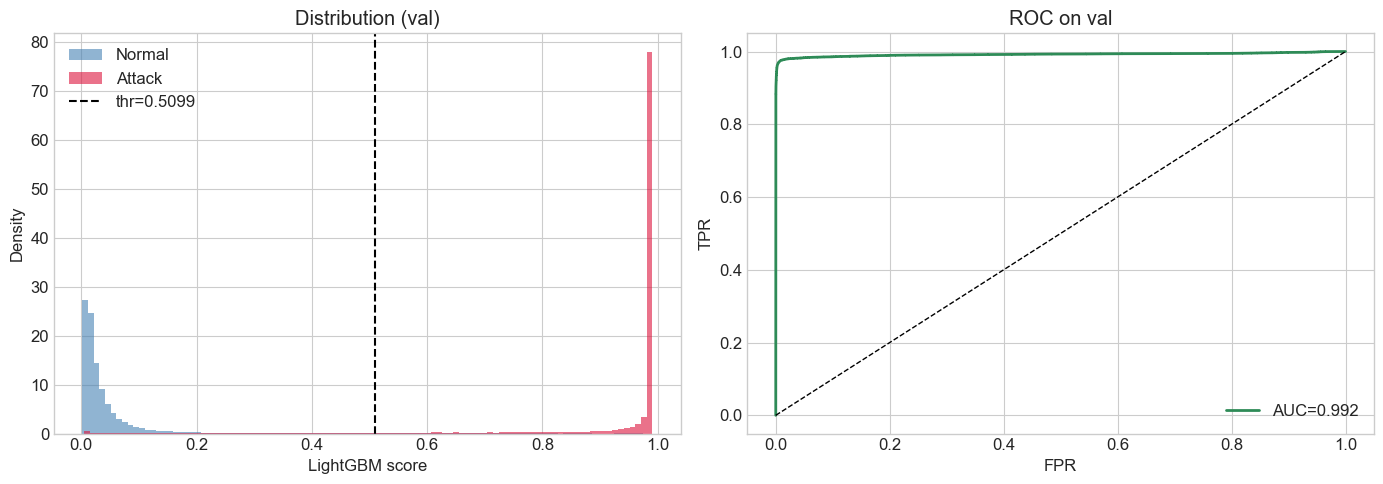

In [6]:
def calibrate_threshold(y_true, scores, beta=1.0):
    '''Return the threshold that maximises F_beta, via the precision-recall curve.'''
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    precisions = precisions[:-1]
    recalls    = recalls[:-1]
    fbeta = ((1 + beta**2) * precisions * recalls /
             (beta**2 * precisions + recalls + 1e-10))
    best_idx = np.argmax(fbeta)
    best_thr = thresholds[best_idx]
    return best_thr, precisions[best_idx], recalls[best_idx], fbeta[best_idx]

scores_val_int  = gbm.predict(X_sup_val_s, num_iteration=gbm.best_iteration)
scores_test     = gbm.predict(X_sup_test_s, num_iteration=gbm.best_iteration)

# Calibrating on the full validation set requires scores for ALL of val,
# not just the held-out 20% used for early stopping.
scores_val_all = gbm.predict(scaler.transform(X_val_df.values),
                              num_iteration=gbm.best_iteration)

best_thr, prec_at, rec_at, fbeta_at = calibrate_threshold(y_val, scores_val_all, beta=1.0)
print(f'best_thr: {best_thr:.6f}  | P={prec_at:.4f} R={rec_at:.4f} F1={fbeta_at:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.hist(scores_val_all[y_val==0], bins=100, alpha=0.6, color='steelblue', density=True, label='Normal')
ax.hist(scores_val_all[y_val==1], bins=100, alpha=0.6, color='crimson',   density=True, label='Attack')
ax.axvline(best_thr, color='k', ls='--', lw=1.5, label=f'thr={best_thr:.4f}')
ax.set(xlabel='LightGBM score', ylabel='Density', title='Distribution (val)')
ax.legend()

ax = axes[1]
fpr, tpr, _ = roc_curve(y_val, scores_val_all)
ax.plot(fpr, tpr, lw=2, color='seagreen', label=f'AUC={roc_auc_score(y_val, scores_val_all):.3f}')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set(xlabel='FPR', ylabel='TPR', title='ROC on val')
ax.legend()
plt.tight_layout(); plt.show()


## 6. Raw Evaluation

LightGBM — RAW
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98    508282
      Attack       0.96      0.87      0.92     96717

    accuracy                           0.97    604999
   macro avg       0.97      0.93      0.95    604999
weighted avg       0.97      0.97      0.97    604999

AUC-ROC: 0.9627  AUC-PR: 0.9408
F1: 0.9151 F2: 0.8904 P: 0.9595 R: 0.8746

Top 10 features by gain:
              feature         gain  split
   vi_res_roll15_mean 1.997345e+06   1831
  gap_intensity_ratio 6.149746e+05   1801
           vi_res_abs 5.036185e+05   1090
             hour_sin 1.581921e+05   2482
             hour_cos 1.414931e+05   2577
  Global_active_power 1.376500e+05   1120
Global_reactive_power 1.375196e+05   1382
              dow_sin 1.194082e+05   1597
          VI_residual 1.051513e+05   1180
       gap_roll30_std 9.937232e+04   1954


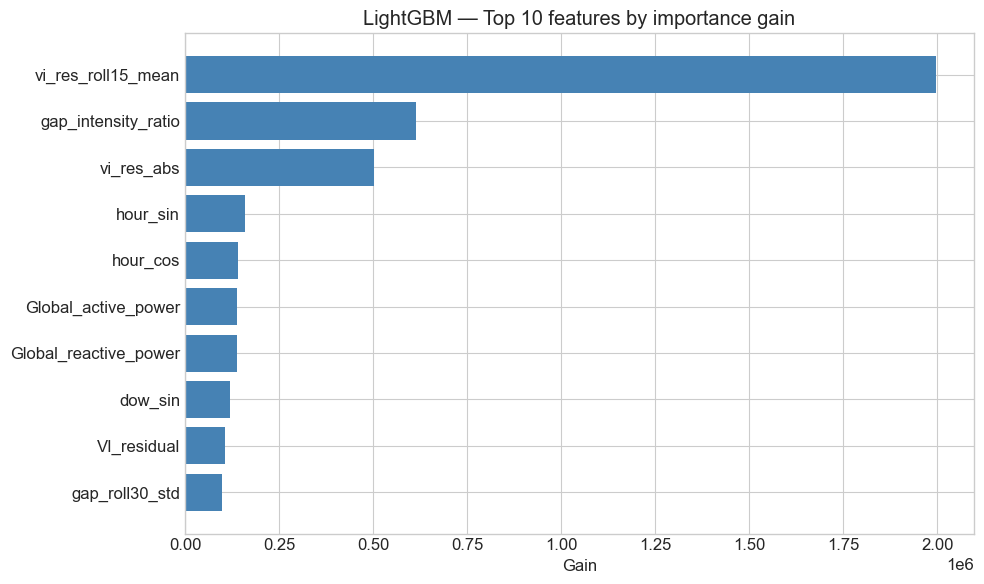

In [7]:
y_pred_raw = (scores_test > best_thr).astype(int)
auc_roc = roc_auc_score(y_test, scores_test)
auc_pr  = average_precision_score(y_test, scores_test)
f1_r  = f1_score(y_test, y_pred_raw)
f2_r  = fbeta_score(y_test, y_pred_raw, beta=2)
prec_r = precision_score(y_test, y_pred_raw)
rec_r  = recall_score(y_test, y_pred_raw)

print('='*60); print('LightGBM — RAW'); print('='*60)
print(classification_report(y_test, y_pred_raw, target_names=['Normal','Attack']))
print(f'AUC-ROC: {auc_roc:.4f}  AUC-PR: {auc_pr:.4f}')
print(f'F1: {f1_r:.4f} F2: {f2_r:.4f} P: {prec_r:.4f} R: {rec_r:.4f}')

# Feature importance: gain (total split gain) and split (number of splits).
importances = pd.DataFrame({
    'feature': ENG_FEATURE_COLS,
    'gain': gbm.feature_importance(importance_type='gain'),
    'split': gbm.feature_importance(importance_type='split'),
}).sort_values('gain', ascending=False)

print('\nTop 10 features by gain:')
print(importances.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top10 = importances.head(10)[::-1]
ax.barh(top10['feature'], top10['gain'], color='steelblue')
ax.set(xlabel='Gain', title='LightGBM — Top 10 features by importance gain')
plt.tight_layout(); plt.show()


## 7. Temporal Voting + Smoothed Evaluation

In [8]:
def temporal_vote_vectorized(y_pred, W, K):
    '''Causal K-of-W voting filter. Runs in O(n) via a prefix sum.'''
    cum = np.concatenate([[0], np.cumsum(y_pred)])
    n = len(y_pred)
    ends = np.arange(1, n + 1)
    starts = np.maximum(0, ends - W)
    votes = cum[ends] - cum[starts]
    return (votes >= K).astype(int)


def grid_search_wk(scores_val, y_val, best_thr, W_grid=(3,5,7,9,11,15,21,30)):
    '''Search the (W, K) voting parameters that maximise F1 on validation.'''
    y_pred_val = (scores_val > best_thr).astype(int)
    best_f1, best_W, best_K = 0, 3, 2
    for W in W_grid:
        for K in range(2, W + 1):
            y_sm = temporal_vote_vectorized(y_pred_val, W, K)
            f1 = f1_score(y_val, y_sm)
            if f1 > best_f1:
                best_f1, best_W, best_K = f1, W, K
    return best_W, best_K, best_f1

best_W, best_K, _ = grid_search_wk(scores_val_all, y_val, best_thr)
print(f'Optimal temporal filter: W={best_W}, K={best_K}')

y_pred_smooth = temporal_vote_vectorized(y_pred_raw, best_W, best_K)
f1_s = f1_score(y_test, y_pred_smooth)
f2_s = fbeta_score(y_test, y_pred_smooth, beta=2)
prec_s = precision_score(y_test, y_pred_smooth)
rec_s  = recall_score(y_test, y_pred_smooth)
print('='*60); print('LightGBM — SMOOTHED'); print('='*60)
print(f'F1: {f1_s:.4f} F2: {f2_s:.4f} P: {prec_s:.4f} R: {rec_s:.4f}')

# -- ITER2 LEVER A: joint search over (threshold x W x K) on val --
# Mirrors NB05: the headline metric is the smoothed per-timestep F1. The fixed
# threshold from cell 12 need not be jointly optimal once voting is applied,
# so we re-optimise threshold and (W, K) together.
print()
print('=' * 60)
print('JOINT SEARCH (threshold x W x K) on val — lever A iter2')
print('=' * 60)

prc_pr_, prc_rc_, prc_thr_ = precision_recall_curve(y_val, scores_val_all)
prc_thr_ = prc_thr_[(prc_thr_ > 0) & (prc_thr_ < 1)]
if len(prc_thr_) < 5:
    thr_candidates = np.linspace(0.05, 0.95, 30)
else:
    thr_candidates = np.unique(np.quantile(
        prc_thr_, np.linspace(0.30, 0.999, 80)))

W_grid_joint = [3, 5, 7, 9, 11, 15, 21, 31, 45, 60]
best_joint_f1 = -1.0
best_joint = (best_thr, best_W, best_K)
n_evals = 0

for thr in thr_candidates:
    preds_val_local = (scores_val_all > thr).astype(int)
    if preds_val_local.sum() == 0 or preds_val_local.sum() == len(preds_val_local):
        continue
    for W in W_grid_joint:
        for K in range(2, W + 1):
            y_sm = temporal_vote_vectorized(preds_val_local, W, K)
            if y_sm.sum() == 0:
                continue
            f1_sm = f1_score(y_val, y_sm)
            n_evals += 1
            if f1_sm > best_joint_f1:
                best_joint_f1 = f1_sm
                best_joint = (thr, W, K)

# Baseline: val F1 under the original (best_thr, best_W, best_K).
preds_val_orig = (scores_val_all > best_thr).astype(int)
y_sm_orig = temporal_vote_vectorized(preds_val_orig, best_W, best_K)
f1_val_orig = f1_score(y_val, y_sm_orig)

print(f'  Evaluations: {n_evals}')
print(f'  Best F1 val smoothed (joint): {best_joint_f1:.4f}')
print(f'  Joint combination: thr={best_joint[0]:.6f}, W={best_joint[1]}, K={best_joint[2]}')
print(f'  Original val F1:              {f1_val_orig:.4f}, thr={best_thr:.6f}, W={best_W}, K={best_K}')

if best_joint_f1 > f1_val_orig:
    best_thr, best_W, best_K = best_joint
    y_pred_raw = (scores_test > best_thr).astype(int)
    print(f'  -> Adopting joint: thr={best_thr:.6f}, W={best_W}, K={best_K}')
else:
    print('  -> Keeping previous calibration (joint search does not improve).')

# Re-apply voting to test with the (possibly updated) (best_thr, best_W, best_K).
y_pred_smooth = temporal_vote_vectorized(y_pred_raw, best_W, best_K)

f1_s = f1_score(y_test, y_pred_smooth)
f2_s = fbeta_score(y_test, y_pred_smooth, beta=2)
prec_s = precision_score(y_test, y_pred_smooth)
rec_s  = recall_score(y_test, y_pred_smooth)
# Recompute raw metrics too, since y_pred_raw may have changed if we adopted the joint result.
f1_r  = f1_score(y_test, y_pred_raw)
f2_r  = fbeta_score(y_test, y_pred_raw, beta=2)
prec_r = precision_score(y_test, y_pred_raw)
rec_r  = recall_score(y_test, y_pred_raw)
print()
print(f'TEST after joint: F1_smoothed={f1_s:.4f} P={prec_s:.4f} R={rec_s:.4f}')
print('=' * 60)


Optimal temporal filter: W=3, K=2
LightGBM — SMOOTHED
F1: 0.9106 F2: 0.8859 P: 0.9550 R: 0.8702

JOINT SEARCH (threshold x W x K) on val — lever A iter2
  Evaluations: 15760
  Best F1 val smoothed (joint): 0.9701
  Joint combination: thr=0.502875, W=3, K=2
  Original val F1:              0.9699, thr=0.509946, W=3, K=2
  -> Adopting joint: thr=0.502875, W=3, K=2

TEST after joint: F1_smoothed=0.9104 P=0.9540 R=0.8706


## 8. Recall by Type x Severity + Latency

In [9]:
def recall_per_type_severity(df_preds, score_col, threshold,
                              attack_types=ATTACK_TYPES,
                              severities=('low','medium','high')):
    '''Recall broken down by (attack type, severity).'''
    rows = []
    for atype in attack_types:
        row = {'type': atype}
        for sev in severities:
            mask = (df_preds['attack_type']==atype) & (df_preds['severity']==sev)
            if mask.sum() == 0:
                row[sev] = np.nan
            else:
                y_true_sub  = df_preds.loc[mask, 'label'].values
                y_score_sub = df_preds.loc[mask, score_col].values
                y_pred_sub  = (y_score_sub > threshold).astype(int)
                row[sev] = recall_score(y_true_sub, y_pred_sub, zero_division=0)
        rows.append(row)
    out = pd.DataFrame(rows).set_index('type')
    print('Recall by type x severity (smoothed):')
    print(out.round(3))
    return out
def compute_detection_latency(df_preds, score_col, threshold):
    '''Per-episode detection latency in minutes (time from episode start to first alarm).'''
    results = []
    attacked = df_preds[df_preds['episode_id'] >= 0]
    for ep_id, group in attacked.groupby('episode_id'):
        group = group.sort_index()
        detections = group[group[score_col] > threshold]
        ep_start = group.index[0]
        results.append({
            'episode_id': ep_id,
            'type': group['attack_type'].iloc[0],
            'severity': group['severity'].iloc[0],
            'duration_min': len(group),
            'latency_min': ((detections.index[0] - ep_start).total_seconds() / 60
                            if len(detections) > 0 else np.nan),
            'detected': len(detections) > 0
        })
    return pd.DataFrame(results)


def print_latency_summary(lat_df):
    det_rate = lat_df['detected'].mean()
    detected = lat_df[lat_df['detected']]
    if len(detected) > 0:
        med_lat = detected['latency_min'].median()
        p90_lat = detected['latency_min'].quantile(0.9)
    else:
        med_lat = p90_lat = np.nan
    print('=' * 65)
    print('DETECTION LATENCY (smoothed)')
    print('=' * 65)
    print(f'  Detection rate: {det_rate*100:.2f}%')
    print(f'  Median:         {med_lat:.1f} min')
    print(f'  P90:            {p90_lat:.1f} min')
    print()
    print('  By attack type:')
    for atype, g in lat_df.groupby('type'):
        gd = g[g['detected']]
        print(f'    {atype:18s} n={len(g):3d}  det={g["detected"].mean()*100:5.1f}%  '
              f'med_lat={gd["latency_min"].median() if len(gd)>0 else float("nan"):5.1f}min')
    return det_rate, med_lat, p90_lat

df_preds_test = df_test[['attack_type','severity','episode_id','label']].copy()
df_preds_test['score']   = scores_test
df_preds_test['pred_sm'] = y_pred_smooth

def recall_per_type_severity_sm(df_preds, pred_col,
                                attack_types=ATTACK_TYPES,
                                severities=('low','medium','high')):
    rows = []
    for atype in attack_types:
        row = {'type': atype}
        for sev in severities:
            mask = (df_preds['attack_type']==atype) & (df_preds['severity']==sev)
            if mask.sum() == 0:
                row[sev] = np.nan
            else:
                row[sev] = recall_score(df_preds.loc[mask,'label'].values,
                                         df_preds.loc[mask,pred_col].values, zero_division=0)
        rows.append(row)
    out = pd.DataFrame(rows).set_index('type')
    print('Recall by type x severity (smoothed):')
    print(out.round(3))
    return out

recall_table = recall_per_type_severity_sm(df_preds_test, 'pred_sm')
lat = compute_detection_latency(df_preds_test, 'score', best_thr)
det_rate, med_lat, p90_lat = print_latency_summary(lat)


Recall by type x severity (smoothed):
                 low  medium   high
type                               
scaling        0.857   0.990  0.990
offset         0.948   0.991  0.992
noise          0.934   0.977  0.983
ramp           0.684   0.800  0.860
step           0.645   0.647  0.603
replay         0.643   0.833  0.905
voltage_spoof  0.989   0.991  0.991
DETECTION LATENCY (smoothed)
  Detection rate: 99.88%
  Median:         0.0 min
  P90:            35.0 min

  By attack type:
    noise              n=120  det=100.0%  med_lat=  0.0min
    offset             n=120  det=100.0%  med_lat=  0.0min
    ramp               n=120  det=100.0%  med_lat= 18.5min
    replay             n=120  det=100.0%  med_lat=  0.0min
    scaling            n=120  det= 99.2%  med_lat=  0.0min
    step               n=120  det=100.0%  med_lat= 38.5min
    voltage_spoof      n=120  det=100.0%  med_lat=  0.0min


## 9. Persisting Artefacts

In [10]:
model_path = os.path.join(DATA_DIR, 'model_lightgbm.txt')
gbm.save_model(model_path, num_iteration=gbm.best_iteration)
size_kb = os.path.getsize(model_path) / 1e3

joblib.dump(scaler, os.path.join(DATA_DIR, 'scaler_lightgbm.pkl'))
np.save(os.path.join(DATA_DIR, 'threshold_lightgbm.npy'), np.array([best_thr]))

# Inference latency (ms/sample). Warm up once, then average over 5 full passes.
_ = gbm.predict(X_sup_test_s[:100], num_iteration=gbm.best_iteration)
times = []
for _ in range(5):
    t0 = time.time()
    gbm.predict(X_sup_test_s, num_iteration=gbm.best_iteration)
    times.append(time.time() - t0)
ms_per_sample = np.mean(times) / len(X_sup_test_s) * 1000

df_preds_out = df_test[['attack_type','severity','episode_id','label']].copy()
df_preds_out['score'] = scores_test
df_preds_out['pred']  = y_pred_smooth
df_preds_out.to_csv(os.path.join(DATA_DIR, 'predictions_lightgbm.csv'))

lat.to_csv(os.path.join(DATA_DIR, 'latency_lightgbm.csv'), index=False)
importances.to_csv(os.path.join(DATA_DIR, 'lgbm_importances.csv'), index=False)

metrics = {
    'model': 'LightGBM (supervised) + Temporal Voting',
    'feature_mode': 'full',
    'note': 'Supervised baseline — comparative yardstick, NOT in final detector',
    'raw_f1':        round(float(f1_r), 4),
    'raw_f2':        round(float(f2_r), 4),
    'raw_precision': round(float(prec_r), 4),
    'raw_recall':    round(float(rec_r), 4),
    'f1':            round(float(f1_s), 4),
    'f2':            round(float(f2_s), 4),
    'precision':     round(float(prec_s), 4),
    'recall':        round(float(rec_s), 4),
    'auc_roc':       round(float(auc_roc), 4),
    'auc_pr':        round(float(auc_pr), 4),
    'threshold':     float(best_thr),
    'temporal_W':    int(best_W),
    'temporal_K':    int(best_K),
    'model_size_kb': round(size_kb, 1),
    'ms_per_sample': round(float(ms_per_sample), 4),
    'best_iteration':int(gbm.best_iteration),
    'n_features':    len(ENG_FEATURE_COLS),
    'train_time_s':  round(t_train, 1),
    'detection_rate':     round(float(det_rate), 4),
    'median_latency_min': float(med_lat) if not np.isnan(med_lat) else None,
    'granularity':   '1 min',
    'feature_names': ENG_FEATURE_COLS,
    'top10_features_by_gain': importances.head(10)['feature'].tolist(),
}
with open(os.path.join(DATA_DIR, 'metrics_lightgbm.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

print('='*55); print('SAVED LightGBM'); print('='*55)
print(f'  Model size:    {size_kb:.1f} KB')
print(f'  ms/sample:     {ms_per_sample:.4f}')


SAVED LightGBM
  Model size:    3110.9 KB
  ms/sample:     0.0025


## 10. Summary

In [11]:
print('='*65)
print('NB09 — LightGBM (supervised): SUMMARY')
print('='*65)
print(f'  AUC-ROC: {auc_roc:.4f}  AUC-PR: {auc_pr:.4f}')
print(f'  F1 raw:  {f1_r:.4f} -> F1 smoothed: {f1_s:.4f}  (W={best_W} K={best_K})')
print(f'  Median latency: {med_lat:.1f} min  | Detection rate: {det_rate*100:.2f}%')
print(f'  Size: {size_kb:.1f} KB  | ms/sample: {ms_per_sample:.4f}')
print()
print('Interpretation:')
print('  - If AUC-PR_lgbm >> AUC-PR_dense_ae: the problem has a high ceiling,')
print('    so the unsupervised models still have room to improve.')
print('  - If the two are close: the autoencoders sit near the best achievable')
print('    performance WITHOUT labels, which is exactly the thesis claim.')


NB09 — LightGBM (supervised): SUMMARY
  AUC-ROC: 0.9627  AUC-PR: 0.9408
  F1 raw:  0.9149 -> F1 smoothed: 0.9104  (W=3 K=2)
  Median latency: 0.0 min  | Detection rate: 99.88%
  Size: 3110.9 KB  | ms/sample: 0.0025

Interpretation:
  - If AUC-PR_lgbm >> AUC-PR_dense_ae: the problem has a high ceiling,
    so the unsupervised models still have room to improve.
  - If the two are close: the autoencoders sit near the best achievable
    performance WITHOUT labels, which is exactly the thesis claim.
